<a href="https://colab.research.google.com/github/R3beAM/Proyecto-Final-Integracion/blob/main/Parte_2_Proyecto_Final_Integracion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Parte 2 — Exploratory Data Analysis (EDA)**



##1. Carga y revisión inicial

In [1]:
import pandas as pd
import numpy as np

import nltk
from nltk.corpus import stopwords

import re
import string

In [2]:
# Ruta al archivo (ajusta el nombre del archivo)
file_path = "/content/Amazon_Consumer_Review.csv"

# Cargar el dataset en Pandas
df = pd.read_csv(file_path)

# Ver las primeras filas
df.head()

,id,dateAdded,dateUpdated,name,asins,brand,categories,primaryCategories,imageURLs,keys,...,reviews.didPurchase,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.username,sourceURLs
0,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,3,https://www.amazon.com/product-reviews/B00QWO9...,I order 3 of them and one of the item is bad q...,... 3 of them and one of the item is bad quali...,Byger yang,"https://www.barcodable.com/upc/841710106442,ht..."
1,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,4,https://www.amazon.com/product-reviews/B00QWO9...,Bulk is always the less expensive way to go fo...,... always the less expensive way to go for pr...,ByMG,"https://www.barcodable.com/upc/841710106442,ht..."
2,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Well they are not Duracell but for the price i...,... are not Duracell but for the price i am ha...,BySharon Lambert,"https://www.barcodable.com/upc/841710106442,ht..."
3,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,Seem to work as well as name brand batteries a...,... as well as name brand batteries at a much ...,Bymark sexson,"https://www.barcodable.com/upc/841710106442,ht..."
4,AVpgNzjwLJeJML43Kpxn,2015-10-30T08:59:32Z,2019-04-25T09:08:16Z,AmazonBasics AAA Performance Alkaline Batterie...,"B00QWO9P0O,B00LH3DMUO",Amazonbasics,"AA,AAA,Health,Electronics,Health & Household,C...",Health & Beauty,https://images-na.ssl-images-amazon.com/images...,"amazonbasics/hl002619,amazonbasicsaaaperforman...",...,NaN,NaN,NaN,NaN,5,https://www.amazon.com/product-reviews/B00QWO9...,These batteries are very long lasting the pric...,... batteries are very long lasting the price ...,Bylinda,"https://www.barcodable.com/upc/841710106442,ht..."


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28332 entries, 0 to 28331
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   28332 non-null  object 
 1   dateAdded            28332 non-null  object 
 2   dateUpdated          28332 non-null  object 
 3   name                 28332 non-null  object 
 4   asins                28332 non-null  object 
 5   brand                28332 non-null  object 
 6   categories           28332 non-null  object 
 7   primaryCategories    28332 non-null  object 
 8   imageURLs            28332 non-null  object 
 9   keys                 28332 non-null  object 
 10  manufacturer         28332 non-null  object 
 11  manufacturerNumber   28332 non-null  object 
 12  reviews.date         28332 non-null  object 
 13  reviews.dateSeen     28332 non-null  object 
 14  reviews.didPurchase  9 non-null      object 
 15  reviews.doRecommend  16086 non-null 

In [4]:
df.describe()

,reviews.id,reviews.numHelpful,reviews.rating
count,4.100000e+01,16115.000000,28332.000000
mean,1.840066e+08,0.529321,4.514048
std,2.337036e+07,9.345017,0.934957
min,1.116244e+08,0.000000,1.000000
25%,1.843344e+08,0.000000,4.000000
50%,1.885078e+08,0.000000,5.000000
75%,1.988160e+08,0.000000,5.000000
max,2.085304e+08,621.000000,5.000000


In [5]:
df.dtypes

,0
id,object
dateAdded,object
dateUpdated,object
name,object
asins,object
brand,object
categories,object
primaryCategories,object
imageURLs,object
keys,object


##Información general del dataset

El dataset anexado corresponde a una base de datos de reseñas de consumidores sobre productos Amazon. Cada fila representa una opinión escrita por un cliente sobre un producto específico, junto con información asociada como calificación, fecha, producto, categoría, marca, recomendación y votos de utilidad.

Este dataset es adecuado para el proyecto porque contiene texto de reseñas, calificaciones numéricas y variables complementarias que permiten desarrollar un modelo de análisis de sentimiento con Machine Learning y NLP.

| Elemento                                   | Descripción                                                            |
| ------------------------------------------ | ---------------------------------------------------------------------- |
| **Nombre del archivo**                     | `Amazon_Consumer_Review.csv`                                           |
| **Formato**                                | CSV                                                                    |
| **Cantidad de filas**                      | 28,332 registros                                                       |
| **Cantidad de columnas**                   | 24 columnas                                                            |
| **Unidad de análisis**                     | Cada fila representa una reseña de un cliente sobre un producto Amazon |
| **Periodo de reseñas**                     | Aproximadamente de 2009 a 2019                                         |
| **Tipo de problema compatible**            | NLP y clasificación multiclase                                         |
| **Variable principal de texto**            | `reviews.text`                                                         |
| **Variable base para construir el target** | `reviews.rating`                                                       |



###¿Qué contiene el dataset?

El dataset contiene información relacionada con:

* Datos del producto
* Nombre del producto.
* Marca.
* Categoría.
* ASIN o identificador del producto.
Fabricante.
* URLs de imágenes y páginas fuente.
* Datos de la reseña
* Texto completo de la reseña.
* Título de la reseña.
* Calificación dada por el cliente.
* Fecha de la reseña.
* Nombre de usuario.
* Cantidad de votos de utilidad.
* Datos de recomendación
* Si el cliente recomienda o no el producto.
* Si el cliente compró el producto, aunque esta variable tiene muchos datos faltantes.

###**Variables mas importantes para el proyecto**

| Variable              | Descripción                                         | Uso en el proyecto                                                 |
| --------------------- | --------------------------------------------------- | ------------------------------------------------------------------ |
| `reviews.text`        | Texto completo de la reseña escrita por el cliente. | Variable principal para aplicar NLP.                               |
| `reviews.title`       | Título de la reseña.                                | Puede complementar el texto principal.                             |
| `reviews.rating`      | Calificación del producto de 1 a 5 estrellas.       | Se usará para construir el target de sentimiento.                  |
| `reviews.doRecommend` | Indica si el cliente recomienda el producto.        | Variable de apoyo para validar sentimiento.                        |
| `reviews.numHelpful`  | Número de votos de utilidad de la reseña.           | Puede analizarse para ver si las reseñas negativas son más útiles. |
| `reviews.date`        | Fecha de la reseña.                                 | Permite analizar cambios de sentimiento en el tiempo.              |
| `name`                | Nombre del producto reseñado.                       | Permite analizar sentimiento por producto.                         |
| `primaryCategories`   | Categoría principal del producto.                   | Permite analizar sentimiento por categoría.                        |

##Observaciones iniciales sobre los datos

1. El dataset tiene buen tamaño para un proyecto de Machine Learning

Con 28,332 reseñas, el dataset es suficientemente grande para entrenar modelos clásicos de clasificación de texto, como:

Regresión Logística,
Naive Bayes,
Random Forest,
XGBoost, si se desea probar una opción más avanzada.

Al mismo tiempo, no es tan grande como para requerir infraestructura compleja. Puede trabajarse adecuadamente en Google Colab usando CPU.

2. La mayoría de las reseñas son positivas

La distribución de calificaciones muestra un fuerte predominio de reseñas positivas.

|      Rating | Cantidad aproximada | Porcentaje |
| ----------: | ------------------: | ---------: |
|  1 estrella |                 965 |      3.41% |
| 2 estrellas |                 616 |      2.17% |
| 3 estrellas |               1,206 |      4.26% |
| 4 estrellas |               5,648 |     19.94% |
| 5 estrellas |              19,897 |     70.23% |

Esto indica que aproximadamente el 90% de las reseñas tienen calificaciones de 4 o 5 estrellas.

*Observación importante*

Esto representa un posible desbalance de clases. Si el target se construye como:

| Rating | Sentimiento |
| -----: | ----------- |
|  1 o 2 | Negativo    |
|      3 | Neutral     |
|  4 o 5 | Positivo    |

3. El texto de las reseñas está completo

Una observación positiva es que la variable principal del proyecto, reviews.text, no presenta valores nulos. Esto es importante porque el modelo dependerá principalmente del texto para aprender patrones de sentimiento.

También la variable reviews.title está completa, por lo que puede utilizarse como complemento del texto principal.

Una estrategia posible sería crear una variable combinada:

`texto_final = reviews.title + " " + reviews.text`

Esto podría enriquecer el contenido usado por el modelo.

4. Algunas variables tienen muchos valores faltantes

Aunque las variables principales están completas, algunas columnas tienen una alta cantidad de valores nulos.

| Variable              | Observación                                                                                     |
| --------------------- | ----------------------------------------------------------------------------------------------- |
| `reviews.didPurchase` | Tiene casi todos los valores faltantes. No se recomienda usarla.                                |
| `reviews.id`          | Tiene muchos valores faltantes. No aporta valor directo al modelo.                              |
| `reviews.doRecommend` | Tiene una cantidad importante de valores faltantes, pero puede usarse en análisis exploratorio. |
| `reviews.numHelpful`  | Tiene valores faltantes, pero puede ser útil para análisis complementario.                      |

No todas las variables del dataset deben usarse en el modelo. Para evitar ruido, conviene seleccionar solo las variables realmente útiles:

* reviews.text
* reviews.title
* reviews.rating
* reviews.date
* reviews.numHelpful
* reviews.doRecommend
* name
* primaryCategories

5. Hay concentración en pocas categorías y productos

El dataset contiene 65 productos únicos, pero algunas reseñas se concentran en productos específicos, especialmente baterías AmazonBasics y tablets Fire.

Las categorías principales más frecuentes son:

| Categoría                    | Cantidad aproximada de registros |
| ---------------------------- | -------------------------------: |
| Electronics                  |                           13,995 |
| Health & Beauty              |                           12,071 |
| Toys & Games, Electronics    |                            1,676 |
| Office Supplies, Electronics |                              386 |
| Electronics, Media           |                              185 |


6. Hay reseñas repetidas o textos duplicados

Aunque no se identificaron filas completamente duplicadas, sí se observan textos de reseñas repetidos. Esto puede ocurrir porque algunos comentarios se repiten para productos similares, variaciones del mismo producto o registros asociados a distintas fuentes.

Implicación

Antes de entrenar el modelo, conviene revisar los duplicados en reviews.text. Si hay demasiados textos repetidos, podrían afectar el aprendizaje del modelo, especialmente si aparecen tanto en entrenamiento como en prueba.

Una posible acción sería eliminar duplicados basados en:

`reviews.text`

o en una combinación de:

`name + reviews.text + reviews.rating`

La longitud de las reseñas es variada

Las reseñas tienen diferentes extensiones. Algunas son muy cortas, de una sola palabra, mientras que otras son bastante largas.

En promedio, las reseñas tienen aproximadamente 26 palabras, aunque hay casos mucho más extensos.

Implicación

Las reseñas muy cortas pueden ser difíciles de clasificar porque tienen poca información contextual. Por ejemplo:

`"Good"`

o

`"Ok"`

Estas reseñas pueden ser positivas o neutrales dependiendo del contexto. Esto puede generar cierta dificultad para el modelo.


##2. Dimensiones y estructura

In [7]:
df_info = pd.DataFrame({
    'Métrica': ['Cantidad de Filas', 'Cantidad de Columnas'],
    'Valor': [df.shape[0], df.shape[1]]
})
display(df_info)

print("Tamaño del dataset:", df.shape)

,Métrica,Valor
0,Cantidad de Filas,28332
1,Cantidad de Columnas,24


Tamaño del dataset: (28332, 24)


Resumen de valores nulos:


,Valores nulos,Porcentaje de nulos
reviews.didPurchase,28323,99.97
reviews.id,28291,99.86
reviews.doRecommend,12246,43.22
reviews.numHelpful,12217,43.12
reviews.username,5,0.02
id,0,0.00
dateUpdated,0,0.00
dateAdded,0,0.00
primaryCategories,0,0.00
categories,0,0.00


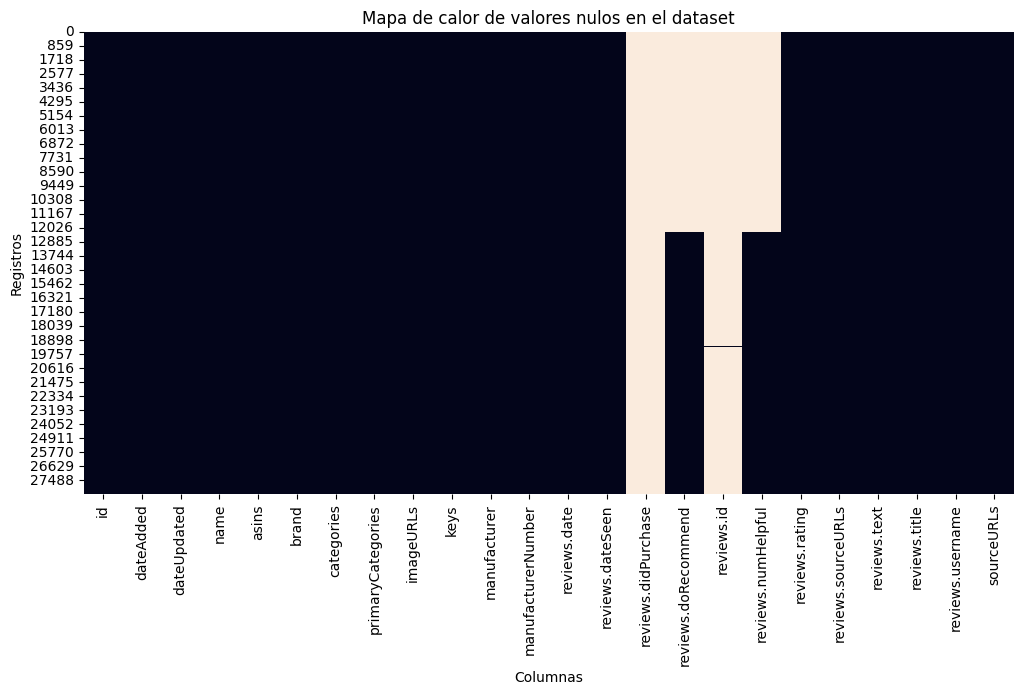

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Amazon_Consumer_Review.csv")

nulos_conteo = df.isnull().sum()
nulos_porcentaje = (df.isnull().sum() / len(df)) * 100

resumen_nulos = pd.DataFrame({
    "Valores nulos": nulos_conteo,
    "Porcentaje de nulos": nulos_porcentaje.round(2)
}).sort_values(by="Porcentaje de nulos", ascending=False)

print("Resumen de valores nulos:")
display(resumen_nulos)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Mapa de calor de valores nulos en el dataset")
plt.xlabel("Columnas")
plt.ylabel("Registros")
plt.show()

***Análisis***

Los resultados muestran que el dataset tiene 24 columnas y que la mayoría de las variables principales para el proyecto están completas. Sin embargo, algunas columnas presentan un porcentaje muy alto de valores nulos y deben tratarse con cuidado.

Las variables de `reviews.didPurchase` y `reviews.id` no se pueden incorporar en el modelo, porque generarían un vicio

| Variable              | Valores nulos | Porcentaje de nulos | Análisis                                                                                                                         |
| --------------------- | ------------: | ------------------: | -------------------------------------------------------------------------------------------------------------------------------- |
| `reviews.didPurchase` |        28,323 |              99.97% | Prácticamente toda la columna está vacía. No es recomendable utilizarla en el análisis ni en el modelo.                          |
| `reviews.id`          |        28,291 |              99.86% | Tiene casi todos los valores faltantes. No aporta valor para el modelo y puede eliminarse.                                       |
| `reviews.doRecommend` |        12,246 |              43.22% | Tiene una cantidad importante de valores nulos. Puede usarse solo como variable complementaria, pero no como variable principal. |
| `reviews.numHelpful`  |        12,217 |              43.12% | Tiene muchos valores faltantes. Puede utilizarse en análisis exploratorio, pero requiere tratamiento de nulos.                   |
| `reviews.username`    |             5 |               0.02% | Tiene muy pocos valores nulos. No representa un problema importante, aunque no es una variable relevante para el modelo.         |


**Variables que pueden conservarse con tratamiento**

Las siguientes variables tienen valores nulos importantes, pero podrían aportar valor en análisis complementarios:

| Variable              | Decisión sugerida                             | Justificación                                                                                                                                                     |
| --------------------- | --------------------------------------------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| `reviews.doRecommend` | Conservar solo para análisis exploratorio.    | Puede ayudar a comparar sentimiento con intención de recomendación, pero no debe ser variable principal por tener 43.22% de nulos.                                |
| `reviews.numHelpful`  | Conservar con imputación o análisis separado. | Puede servir para analizar si las reseñas negativas reciben más votos de utilidad. Los nulos podrían reemplazarse por 0 si se interpreta que no recibieron votos. |

**Variables principales completas**

Una observación muy positiva es que las variables más importantes para el proyecto no tienen valores nulos:

| Variable            | Porcentaje de nulos | Importancia                                            |
| ------------------- | ------------------: | ------------------------------------------------------ |
| `reviews.text`      |               0.00% | Variable principal para NLP y análisis de sentimiento. |
| `reviews.title`     |               0.00% | Puede complementar el texto de la reseña.              |
| `reviews.rating`    |               0.00% | Variable clave para construir el target `sentiment`.   |
| `reviews.date`      |               0.00% | Permite análisis temporal.                             |
| `name`              |               0.00% | Permite análisis por producto.                         |
| `primaryCategories` |               0.00% | Permite análisis por categoría.                        |
| `brand`             |               0.00% | Permite análisis por marca.                            |

**Plan potencial de limpieza**

| Acción                   | Variable              | Justificación                                                |
| ------------------------ | --------------------- | ------------------------------------------------------------ |
| Eliminar                 | `reviews.didPurchase` | 99.97% de nulos.                                             |
| Eliminar                 | `reviews.id`          | 99.86% de nulos.                                             |
| Conservar                | `reviews.text`        | Variable principal del modelo.                               |
| Conservar                | `reviews.title`       | Puede mejorar el contexto textual.                           |
| Conservar                | `reviews.rating`      | Necesaria para construir el target.                          |
| Conservar con cuidado    | `reviews.doRecommend` | Útil para análisis complementario, pero con 43.22% de nulos. |
| Conservar con imputación | `reviews.numHelpful`  | Puede reemplazarse nulos por 0 para análisis exploratorio.   |
| Opcional eliminar        | `reviews.username`    | No aporta al modelo y puede excluirse por privacidad.        |


##**Datos duplicados**

In [11]:
# Conteo de filas completamente duplicadas
duplicados_completos = df.duplicated().sum()

print("Cantidad de registros completamente duplicados:", duplicados_completos)
print("Porcentaje de registros duplicados:", round((duplicados_completos / len(df)) * 100, 2), "%")

Cantidad de registros completamente duplicados: 0
Porcentaje de registros duplicados: 0.0 %


In [14]:
#Datos duplicados en la columna de review.text

# Conteo de textos duplicados en reviews.text
duplicados_texto = df["reviews.text"].duplicated().sum()

print("Cantidad de reseñas duplicadas en reviews.text:", duplicados_texto)
print("Porcentaje de reseñas duplicadas:", round((duplicados_texto / len(df)) * 100, 2), "%")

#Ver cuales textos estan duplicados

# Mostrar todas las filas donde reviews.text está duplicado
df_textos_duplicados = df[df["reviews.text"].duplicated(keep=False)]

# Ordenar para ver juntos los textos repetidos
df_textos_duplicados = df_textos_duplicados.sort_values(by="reviews.text")

df_textos_duplicados[["name", "reviews.rating", "reviews.title", "reviews.text"]].head(20)

#Ver un texto duplicado específico con sus filas completas

# Contar la frecuencia de cada texto para encontrar los repetidos
textos_repetidos = df["reviews.text"].value_counts()
textos_repetidos = textos_repetidos[textos_repetidos > 1]

# Seleccionar el texto duplicado más frecuente
texto_mas_repetido = textos_repetidos.index[0]

# Mostrar las filas donde aparece ese texto
df[df["reviews.text"] == texto_mas_repetido][
    ["name", "reviews.rating", "reviews.title", "reviews.text", "reviews.date"]
]


Cantidad de reseñas duplicadas en reviews.text: 10164
Porcentaje de reseñas duplicadas: 35.87 %


,name,reviews.rating,reviews.title,reviews.text,reviews.date
1708,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2015-10-01T00:00:00.000Z
1709,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-02-17T00:00:00.000Z
1710,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2015-03-24T00:00:00.000Z
1712,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-09-11T00:00:00.000Z
1713,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-10-10T00:00:00.000Z
1715,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-02-01T00:00:00.000Z
1716,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2017-05-02T00:00:00.000Z
1719,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-05-21T00:00:00.000Z
1721,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2016-07-24T00:00:00.000Z
1722,AmazonBasics AAA Performance Alkaline Batterie...,5,Five Stars,good,2017-06-12T00:00:00.000Z


Aunque podría eliminar las entradas duplicadas basados en reviews.text, creo que hay que dejarlos, porque son entradas diferentes, simplemente `good` parece ser un comentario generico muy utilizado

In [ ]:
##Analisis univariado

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

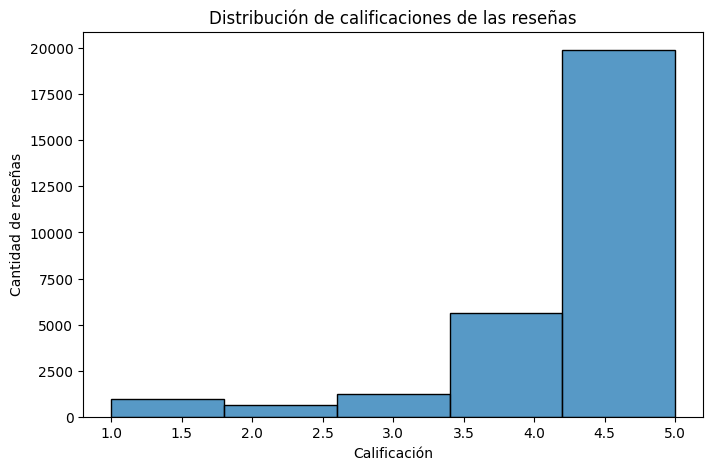

In [16]:
#Histograma de calificaciones reviews.rating

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="reviews.rating",
    bins=5
)

plt.title("Distribución de calificaciones de las reseñas")
plt.xlabel("Calificación")
plt.ylabel("Cantidad de reseñas")
plt.show()

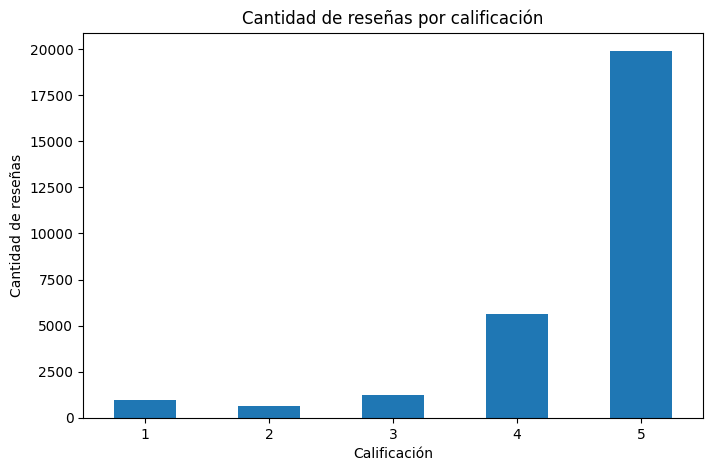

In [17]:
#Grafico de barras de calificaciones

plt.figure(figsize=(8, 5))

df["reviews.rating"].value_counts().sort_index().plot(kind="bar")
3559
plt.title("Cantidad de reseñas por calificación")
plt.xlabel("Calificación")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.show()

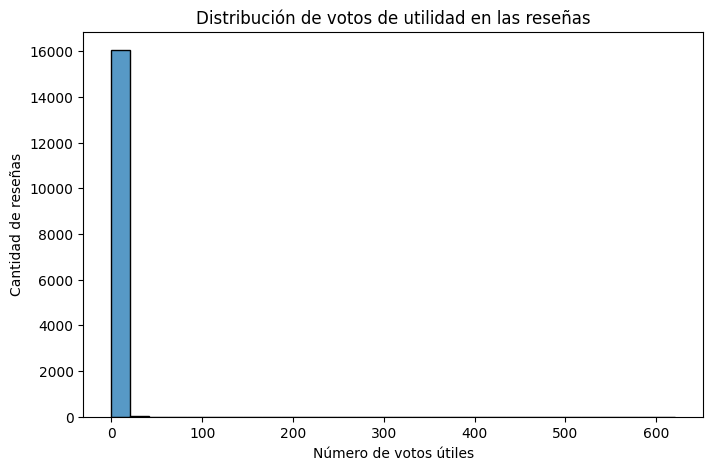

In [18]:
#Histograma de votos útiles reviews.numHelpful

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="reviews.numHelpful",
    bins=30
)

plt.title("Distribución de votos de utilidad en las reseñas")
plt.xlabel("Número de votos útiles")
plt.ylabel("Cantidad de reseñas")
plt.show()

**Analisis**

La mayoria de las reseñas son positivas, y los votos de utilidad parecen ser inexistentes. Contrario a la hipotesis inicial, la mayoría de las reseñas son positivas, y eso puede generar un sesgo en el modelo. Sin embargo, tenerlo claro puede ayudar a gestionarlo

In [19]:
#Creando variable de sentimiento

def clasificar_sentimiento(rating):
    if rating in [1, 2]:
        return "Negativo"
    elif rating == 3:
        return "Neutral"
    elif rating in [4, 5]:
        return "Positivo"
    else:
        return "Sin clasificar"

df["sentiment"] = df["reviews.rating"].apply(clasificar_sentimiento)

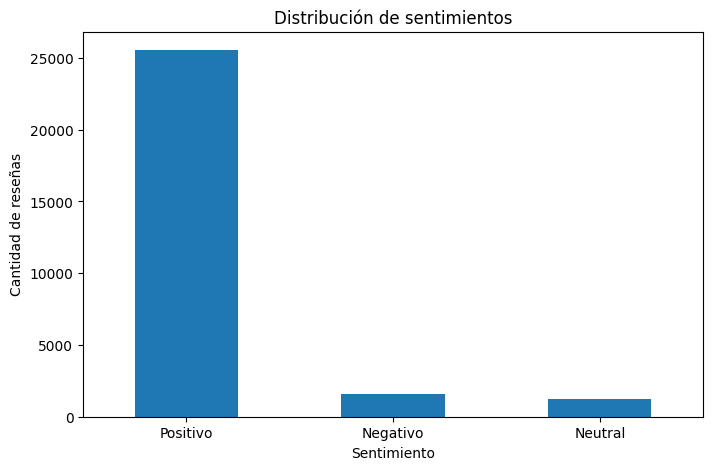

In [20]:
#Distribucion de sentimiento

plt.figure(figsize=(8, 5))

df["sentiment"].value_counts().plot(kind="bar")

plt.title("Distribución de sentimientos")
plt.xlabel("Sentimiento")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=0)
plt.show()

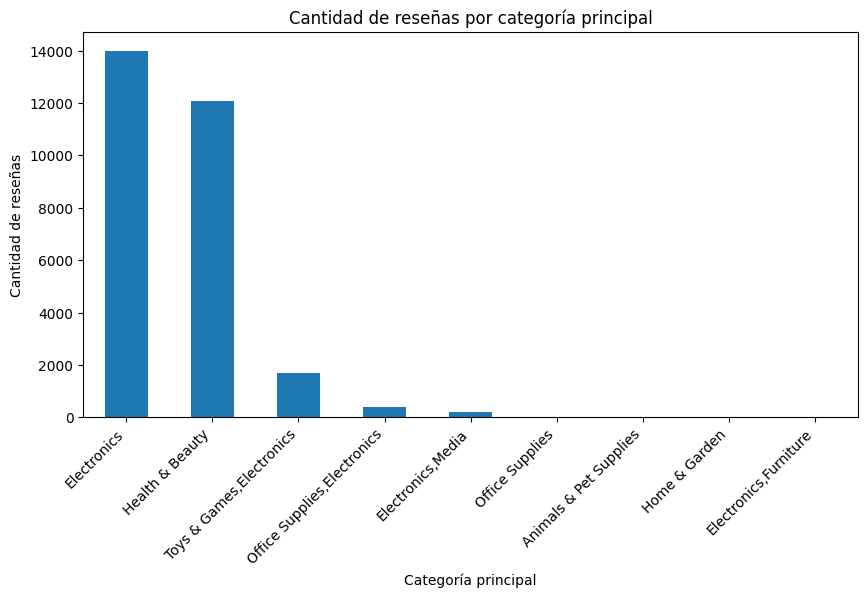

In [21]:
#Histograma por categoría principal

plt.figure(figsize=(10, 5))

df["primaryCategories"].value_counts().plot(kind="bar")

plt.title("Cantidad de reseñas por categoría principal")
plt.xlabel("Categoría principal")
plt.ylabel("Cantidad de reseñas")
plt.xticks(rotation=45, ha="right")
plt.show()

La mayoria de las reseñas estan asociadas a Electronics, entonces podriamos decir que Electronics es la categoria principal con mas reseñas. En esta categoria, Amazon es el principal vendedor, siendo así, el resultado del modelo podria quedar como beneficio interno para la compañía